# Phase 6: Phaseless DSM-DL for Inverse Scattering

**Project**: Demystifying Iterative Direct Sampling Methods — From Theory to Code  
**Reference**: Ning, Han, and Zou, *A Direct Sampling Method and Its Integration with Deep Learning for Inverse Scattering Problems with Phaseless Data* (arXiv:2403.02584, v2)  
**Objective**: Build a tutorial-style Python implementation of Section 5 and port the provided MATLAB/PyTorch reference pipeline into clean Python modules.

---

Phase 6 extends Phases 1–5 from elliptic/parabolic IDSM to **phaseless inverse scattering**. On
$$
\Omega=[-1,1]^2,
$$
we use the paper models:

- **impenetrable scatterers**
$$
\Delta u + k^2u=0\ \text{in }\mathbb R^2\setminus D,\qquad
u|_{\partial D}=0\ (\text{soft})\ \text{or}\ \partial_\nu u|_{\partial D}=0\ (\text{hard}),
$$
- **inhomogeneous medium**
$$
\Delta u + k^2 n(x)u=0\ \text{in }\mathbb R^2\quad (\text{Eq. 2.4}).
$$

We only observe noisy magnitudes on a receiver circle $\Gamma_r$:
$$
|u_\delta(x_r)|=|u(x_r)|+\delta\,\zeta(x_r)\,\|u\|_2\quad (\text{Eq. 5.1}).
$$
The phaseless DSM index uses
$$
\Delta(x_r,d)=\frac{|u|^2-|u^i|^2}{u^i}\quad (\text{Eq. 3.12}),\qquad
I^{\text{phaseless}}_{\text{DSM}}(z)=\left|\int_{\Gamma_r}G(z,x_r)\Delta(x_r,d)\,ds\right|\quad (\text{Eq. 3.11}).
$$

DSM-DL then learns the map
$$
\{I_{\text{DSM},i}\}_{i=1}^{N_i}\longrightarrow n(x)
$$
with U-Net and Eq. (4.1):

$$
\mathrm{Loss}
=\frac{1}{T_n}\sum_{i=1}^{T_n}
\left[
\|X_i-Y_i\|_2^2
+\alpha_1\operatorname{TV}(X_i)
+\alpha_2\left(1-\operatorname{SSIM}(X_i,Y_i)\right)
\right],
\qquad \alpha_1=\alpha_2=0.5.
$$

This notebook keeps the same teaching style as 01–05:

1. theory block with equation-to-code mapping,
2. runnable DSM experiments (Section 5.1),
3. paper-scale outputs loaded from scripts,
4. concise summary of the verified numerical outputs.

### Two executable Python paths in this repository

- **Paper path**: `scripts/run_phaseless_full_repro.py` + `src/phaseless_scattering.py` + `src/phaseless_dsmdl.py`.
- **Reference-code path**: `scripts/run_phaseless_forward_generate.py` + `scripts/run_phaseless_port_repro.py` + `src/phaseless_reference.py`.

Both are pure Python. The paper path is used for Fig.2–10 and Table 1–2 comparison.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, os.path.abspath('..'))

from src.plot_style import apply_idsm_plot_style, save_figure, contrast_norm
from src.phaseless_scattering import (
    PhaselessDSMConfig,
    example_specs,
    run_example_dsm_paper,
    topk_peak_hit_rate,
    peak_location_error,
)
from src.phaseless_dsmdl import DatasetConfig  # used downstream when describing strict-protocol settings

apply_idsm_plot_style()
FIG_DIR = Path('../figures/06_phaseless')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('torch:', torch.__version__)
print('figure dir:', FIG_DIR.resolve())

torch: 2.5.1+cu121
figure dir: /data1/liulingfeng/cooperation/ghy/IDSM-easy-to-begin/figures/06_phaseless


## Theory-to-Code Workflow 

Every major formula block in this notebook follows the same path:

1. paper statement and symbols,
2. function contract,
3. explicit intermediate computation,
4. wrapper validation,
5. full experiment/cached figures,
6. formula-to-code mapping.

## 1. Paper Track: Forward Physics and Phaseless DSM

For a penetrable medium, Paper Eq. (2.4) is

$$
\Delta u+k^2n(x)u=0
\qquad\text{in }\mathbb{R}^N.
$$

For an impenetrable obstacle, Eq. (2.3) supplies the boundary condition

$$
u=0\quad\text{(sound soft)},
\qquad
\partial_\nu u=0\quad\text{(sound hard)}.
$$

The noisy magnitude, corrected data, single-incidence indicator, and multi-incidence average are

$$
|u_\delta(x)|=|u(x)|+\delta\zeta(x)\|u\|_2,
$$

$$
\Delta(x_r,d)=\frac{|u(x_r,d)|^2-|u^i(x_r,d)|^2}{u^i(x_r,d)},
$$

$$
I_{\mathrm{DSM}}^{\mathrm{phaseless}}(z)
=\left|\int_{\Gamma_r}G(z,x_r)\Delta(x_r,d)\,ds(x_r)\right|,
$$

$$
I(z)=\frac1{N_i}\sum_{i=1}^{N_i}I_i(z).
$$

Public function contracts:

- `PhaselessBatchSimulator.forward_total_at_receivers(labels, angle) -> (B,N_r)` uses the same LU-discretized VIE as the paper wrapper;
- `add_phaseless_noise(abs_total, noise_level, rng) -> (N_r,)`;
- `corrected_phaseless_data(abs_total, abs_incident, incident_complex) -> (N_r,)`;
- `compute_phaseless_dsm_indicator(receiver_points, delta, scan_points, k) -> (N_z,)`;
- `run_example_dsm_paper(...) -> dict` is the high-level wrapper;
- `src.phaseless_bie.solve_sound_soft` and `evaluate_total_at` implement the obstacle BIE path.

In [2]:
from src.phaseless_scattering import (
    PhaselessBatchSimulator,
    add_phaseless_noise,
    compute_phaseless_dsm_indicator,
    corrected_phaseless_data,
    example_specs,
    incident_plane_wave,
    make_incident_angles,
    make_receiver_points,
    make_refractive_index,
    make_uniform_grid,
    normalize_indicator,
    run_example_dsm_paper,
)
from src import phaseless_bie as bie

# Medium VIE: execute Eqs. (5.1), (3.12), (3.11), and (5.2) separately.
scan_size = 32
n_receivers = 40
n_incident = 2
wavelength = 0.75
receiver_radius = 4.0
k = 2.0 * np.pi / wavelength

gx_step, gy_step, scan_points_step = make_uniform_grid(scan_size, extent=1.0)
receiver_points_step = make_receiver_points(receiver_radius, n_receivers)
medium_spec = example_specs()["ex1_medium_square"]
medium_label = make_refractive_index(scan_points_step, medium_spec).reshape(scan_size, scan_size).astype(np.float32)
angles_step = make_incident_angles(n_incident)

simulator_step = PhaselessBatchSimulator(
    wavelength=wavelength,
    scan_grid_size=scan_size,
    forward_grid_size=48,
    receiver_radius=receiver_radius,
    n_receivers=n_receivers,
    solve_batch=1,
    device="cpu",
)

rng_step = np.random.default_rng(3)
indicator_per_incidence = []
for angle in angles_step:
    total_field = simulator_step.forward_total_at_receivers(medium_label, float(angle))[0]
    incident_field = incident_plane_wave(receiver_points_step, k=k, angle=float(angle))
    noisy_magnitude = add_phaseless_noise(
        np.abs(total_field), noise_level=0.05, rng=rng_step,
    )
    corrected = corrected_phaseless_data(
        noisy_magnitude, np.abs(incident_field), incident_field,
    )
    indicator_per_incidence.append(
        compute_phaseless_dsm_indicator(
            receiver_points_step, corrected, scan_points_step, k=k,
        )
    )

manual_indicator = normalize_indicator(
    np.mean(np.stack(indicator_per_incidence), axis=0)
).reshape(scan_size, scan_size)

wrapped_indicator = run_example_dsm_paper(
    example_key="ex1_medium_square",
    noise_level=0.05,
    n_incident=n_incident,
    seed=3,
    wavelength=wavelength,
    receiver_radius=receiver_radius,
    n_receivers=n_receivers,
    scan_grid_size=scan_size,
    device="cpu",
)["indicator"]

np.testing.assert_allclose(manual_indicator, wrapped_indicator, rtol=1e-5, atol=1e-6)
print("strict VIE manual-wrapper max difference:", np.max(np.abs(manual_indicator - wrapped_indicator)))
print("per-incidence / averaged shapes:", np.stack(indicator_per_incidence).shape, manual_indicator.shape)

# Sound-soft BIE: use the released boundary condition in Eq. (2.3).
soft_spec = example_specs()["ex2_sound_soft_squares"]
parts = [
    bie.boundary_square(shape["center"], float(shape["half_width"]), n_per_side=20)
    for shape in soft_spec.shapes
]
boundary_points, boundary_normals, boundary_lengths = bie.stack_boundaries(parts)
phi = bie.solve_sound_soft(
    boundary_points, boundary_lengths, k, float(angles_step[0]),
)
total_bie = bie.evaluate_total_at(
    receiver_points_step, boundary_points, boundary_lengths,
    phi, k, float(angles_step[0]),
)
assert np.all(np.isfinite(total_bie))
print("BIE boundary dofs / receiver field:", boundary_points.shape[0], total_bie.shape)

strict VIE manual-wrapper max difference: 3.0078152571388905e-07
per-incidence / averaged shapes: (2, 1024) (32, 32)
BIE boundary dofs / receiver field: 160 (40,)


### Paper Formula-to-Code Map

$$
\Delta u+k^2n(x)u=0
$$

maps to `PhaselessBatchSimulator.forward_total_at_receivers` for media, while the displayed obstacle boundary conditions map to `src.phaseless_bie`.

$$
|u_\delta|=|u|+\delta\zeta\|u\|_2
$$

maps to `add_phaseless_noise`.

$$
\Delta=\frac{|u|^2-|u^i|^2}{u^i}
$$

maps to `corrected_phaseless_data`.

$$
I_i(z)=\left|\int_{\Gamma_r}G(z,x_r)\Delta(x_r,d_i)\,ds\right|,
\qquad
I(z)=\frac1{N_i}\sum_i I_i(z)
$$

maps to `compute_phaseless_dsm_indicator` followed by `numpy.mean`. The numerical assertion above compares this low-level chain with `run_example_dsm_paper` using the same strict VIE, receiver quadrature, incidences, and random stream.

## 2. Paper DSM-DL: Dataset, U-Net, Loss, and Metrics

For polygon data, labels take values in $\{0,1,3\}$ for sound-soft, background, and medium pixels. The input has shape $(N,N_i,H,W)$: one DSM channel per incidence.

**Paper Eq. (4.1)**

$$
\mathrm{Loss}
=\frac1{T_n}\sum_{i=1}^{T_n}
\left[
\|X_i-Y_i\|_2^2
+\alpha_1\operatorname{TV}(X_i)
+\alpha_2\left(1-\operatorname{SSIM}(X_i,Y_i)\right)
\right].
$$

**Paper Eq. (5.3)**

$$
R_e(X,Y)=\frac{\|X-Y\|_2}{\|Y\|_2}.
$$

**Paper Eq. (5.4)**

$$
\operatorname{Acc}(X,Y)
=\frac1{N_{d_x}N_{d_y}}\sum_{i,j}a_{i,j},
\qquad
a_{i,j}=\begin{cases}1,&X_{i,j}=Y_{i,j},\\0,&\text{otherwise}.
\end{cases}
$$

`UNetDSMDL.forward_with_trace` exposes every encoder, pool, bottleneck, upsample, and decoder shape. The short run below is only a deterministic mechanics check; paper-scale metrics are loaded later from the full training artifacts.

In [3]:
import torch
import torch.nn.functional as F

from src.phaseless_dsmdl import (
    DatasetConfig,
    TrainingConfig,
    UNetDSMDL,
    compute_strict_dsm_inputs_with_meta,
    generate_polygon_labels_with_meta,
    make_dataset_tensors,
    make_polygon_dataloader,
    pixel_accuracy,
    predict,
    relative_l2_error,
    ssim_loss,
    threshold_to_classes,
    train_unet,
    tv_loss,
)

paper_dataset_cfg = DatasetConfig(
    image_size=32,
    n_incident=3,
    wavelength=0.75,
    forward_grid_size=20,
    receiver_radius=4.0,
    n_receivers=40,
    solve_batch=4,
    seed=5,
    device="cpu",
    mnist_download=False,
)
labels_demo, metadata_demo = generate_polygon_labels_with_meta(12, paper_dataset_cfg)
inputs_demo, W_demo = compute_strict_dsm_inputs_with_meta(
    labels_demo,
    metadata_demo,
    cfg=paper_dataset_cfg,
    noise_level=0.01,
    seed=5,
    phased=False,
)
x_demo, y_demo = make_dataset_tensors(inputs_demo, labels_demo)
print("label values / tensor shapes:", np.unique(labels_demo), x_demo.shape, y_demo.shape)

paper_model_demo = UNetDSMDL(
    in_channels=paper_dataset_cfg.n_incident,
    out_channels=1,
    base_channels=16,
    depth=3,
)
pred0, stage_shapes = paper_model_demo.forward_with_trace(x_demo[:2])
for stage, shape in stage_shapes.items():
    print(f"{stage:>12s}: {shape}")

mse0 = F.mse_loss(pred0, y_demo[:2])
tv0 = tv_loss(pred0)
ssim0 = ssim_loss(pred0, y_demo[:2])
print("loss terms before training:", float(mse0), float(tv0), float(ssim0))

train_loader, val_loader = make_polygon_dataloader(
    x_demo, y_demo, batch_size=4, val_fraction=0.25, seed=5,
)
training_demo_cfg = TrainingConfig(
    epochs=8,
    batch_size=4,
    learning_rate=1e-3,
    lr_step=3,
    lr_gamma=0.5,
    alpha_tv=0.5,
    alpha_ssim=0.5,
    device="cpu",
    seed=5,
)
history_demo = train_unet(
    paper_model_demo, train_loader, val_loader, training_demo_cfg,
)
print("training loss:", history_demo["train_loss"])
assert np.isfinite(history_demo["train_loss"]).all()
assert history_demo["train_loss"][-1] < history_demo["train_loss"][0]

prediction_demo = predict(paper_model_demo, x_demo, device="cpu", batch_size=4)
mechanics_rel_l2 = relative_l2_error(prediction_demo, labels_demo)
mechanics_accuracy = pixel_accuracy(
    threshold_to_classes(prediction_demo), threshold_to_classes(labels_demo),
)
print("mechanics-only relative L2 / accuracy:", mechanics_rel_l2, mechanics_accuracy)
print("paper input normalization W:", W_demo)

label values / tensor shapes: [0. 1. 3.] torch.Size([12, 3, 32, 32]) torch.Size([12, 1, 32, 32])
       input: (2, 3, 32, 32)
   encoder_1: (2, 16, 32, 32)
      pool_1: (2, 16, 16, 16)
   encoder_2: (2, 32, 16, 16)
      pool_2: (2, 32, 8, 8)
   encoder_3: (2, 64, 8, 8)
      pool_3: (2, 64, 4, 4)
  bottleneck: (2, 128, 4, 4)
  upsample_1: (2, 64, 8, 8)
   decoder_1: (2, 64, 8, 8)
  upsample_2: (2, 32, 16, 16)
   decoder_2: (2, 32, 16, 16)
  upsample_3: (2, 16, 32, 32)
   decoder_3: (2, 16, 32, 32)
      output: (2, 1, 32, 32)
loss terms before training: 2.642038583755493 0.5576590895652771 0.9560722708702087


training loss: [2.809447447458903, 2.391218344370524, 2.1808793544769287, 2.0118611653645835, 1.9233375787734985, 1.8109391927719116, 1.7680785655975342, 1.723041256268819]
mechanics-only relative L2 / accuracy: 1.0264462647012216 0.043050130208333336
paper input normalization W: 0.3593288958082662


## 3. Released MoM + `U_Net3Ab` Path

This path follows the supplied files directly and uses only `src.phaseless_reference` in executable cells.

- `annulus_gen_rand.m` lines 10–27: Cartesian grid, random radius/center/permittivity, and circle mask;
- `DataMnist.m` lines 9–26: $\eta_0$, $k_0$, $N_r=100$, $N_i=16$, $64\times64$ grid, and cell area;
- `DataMnist.m` lines 40–58: MNIST contrast randomization, extra circle, and

$$
\xi=-\mathrm{i}\omega(\epsilon_r-1)\epsilon_0\,\Delta A;
$$

- `DataMnist.m` lines 65–76: radius-4 receiver ring and plane-wave incidences;
- `DataMnist.m` lines 100–118: MoM Green matrix, self-cell correction, linear solve, and receiver matrix;
- `main.py` lines 43–50: incidence selection and Green-matrix normalization

$$
G_s=R_{\mathrm{mat}}
\left|\operatorname{mean}(R_{\mathrm{mat}}^2)^{1/2}\right|^{-1};
$$

- `main.py` lines 53–68: total magnitude, corrected field, and 1% Gaussian noise;
- `main.py` lines 77–99: matrix indicator, transpose/reshape, and fixed input scaling $2/500$;
- `network.py` lines 453–494: four encoder blocks, three decoder blocks, skip concatenations, $1\times1$ output, and final ReLU;
- `main.py` lines 115–151: Adam, `StepLR(step_size=3, gamma=0.5)`, contiguous batches, train/test relative errors, and best-test checkpoint;
- `colorMap.py` lines 1–240: the `parula` plotting palette.

The paper loss uses $\alpha_1=\alpha_2=0.5$, while the supplied `main.py` line 137 uses $0.05$ for both TV and SSIM. Both settings are retained explicitly rather than silently merged.

In [4]:
from src.phaseless_reference import (
    ForwardConfig,
    TrainingConfigLegacy,
    UNet3Ab,
    annulus_gen_rand,
    compute_inputs_from_fields,
    generate_forward_dataset,
    select_incidence_indices,
    train_unet3ab,
)

# Small but fully physical MoM dataset: no random placeholder E_i/E_s/R_mat arrays.
reference_forward_cfg = ForwardConfig(
    mx=16,
    n_receivers=40,
    n_incident=4,
    max_extent=1.0,
    receiver_radius=4.0,
)
contrast_seed = np.ones((4, 16, 16), dtype=np.float32)
contrast_seed[0, 5:10, 6:9] = 1.4
contrast_seed[1, 3:7, 3:7] = 1.5
contrast_seed[2, 8:13, 9:13] = 1.3
contrast_seed[3, 4:12, 7:9] = 1.6

forward_fields = generate_forward_dataset(
    contrast_seed, cfg=reference_forward_cfg, seed=13,
)
reference_inputs = compute_inputs_from_fields(
    e_i=forward_fields["E_i"],
    e_s=forward_fields["E_s"],
    r_mat=forward_fields["R_mat"],
    n_incident=4,
    noise_level=0.01,
    mm_scale=500.0,
    seed=13,
)
print("incidence indices:", select_incidence_indices(4, 4))
print("field shapes:", forward_fields["E_i"].shape, forward_fields["E_s"].shape, forward_fields["R_mat"].shape)
print("DSM input shape / scale:", reference_inputs["inputs_noisy"].shape, 2.0 / reference_inputs["mm_scale"])

reference_model = UNet3Ab(img_ch=4, output_ch=1, n_ch=8)
reference_x = torch.from_numpy(reference_inputs["inputs_noisy"])
reference_output, reference_trace = reference_model.forward_with_trace(reference_x[:1])
for stage, shape in reference_trace.items():
    print(f"{stage:>12s}: {shape}")

reference_train_cfg = TrainingConfigLegacy(
    n_incident=4,
    batch_size=1,
    batch_number=3,
    epochs=2,
    learning_rate=1e-3,
    step_size=1,
    gamma=0.5,
    noise_level=0.01,
    tv_weight=0.05,
    ssim_weight=0.05,
    mm_scale=500.0,
    train_size=3,
    test_start=3,
    test_stop=4,
    seed=13,
    device="cpu",
    n_channels=8,
)
reference_training = train_unet3ab(
    inputs_noisy=reference_inputs["inputs_noisy"],
    contrast=forward_fields["Contrast"],
    cfg=reference_train_cfg,
)
print("reference learning rates:", reference_training["history"]["lr"])
print("reference test relative L2:", reference_training["history"]["test_rel_l2"])
print("best checkpoint criterion:", reference_training["best_test_rel_l2"])

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(forward_fields["Contrast"][0], origin="lower", cmap="viridis")
axes[0].set_title("MoM contrast")
axes[1].imshow(reference_inputs["inputs_noisy"][0, 0], origin="lower", cmap="viridis")
axes[1].set_title("DSM channel 1")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

incidence indices: [0, 1, 2, 3]
field shapes: (40, 4, 4) (40, 4, 4) (40, 256)
DSM input shape / scale: (4, 4, 16, 16) 0.004


       input: (1, 4, 16, 16)
   encoder_1: (1, 8, 16, 16)
   encoder_2: (1, 16, 8, 8)
   encoder_3: (1, 32, 4, 4)
   encoder_4: (1, 64, 2, 2)
   decoder_3: (1, 32, 4, 4)
   decoder_2: (1, 16, 8, 8)
   decoder_1: (1, 8, 16, 16)
      output: (1, 1, 16, 16)


reference learning rates: [0.0005, 0.00025]
reference test relative L2: [1.0, 1.0]
best checkpoint criterion: 1.0


## 4. Paper Path and Released-Code Path: What Differs

| Component | Paper path | Released MoM/training path |
|---|---|---|
| Physics | Acoustic Helmholtz medium and obstacle problems | Electromagnetic MoM discretization in `DataMnist.m` |
| Forward solver | Dense VIE for media; BIE for sound-soft/hard obstacles | Cell-based Green matrix with analytic self-cell correction |
| Corrected data | $\Delta=(|u|^2-|u^i|^2)/u^i$ | Same corrected-data expression in `main.py` |
| DSM channels | One channel per plane-wave incidence | Matrix product `deltaE.T @ Gs`, then reshape/transposes |
| Input normalization | Training-set maximum $2/W$ | Fixed $2/500$ |
| Network | Standard U-Net used for paper datasets | `U_Net3Ab` from `network.py` |
| Loss weights | $\alpha_1=\alpha_2=0.5$ | TV and SSIM weights $0.05$ |
| Model selection | Paper-scale final experiment protocol | Smallest test relative error checkpoint in `main.py` |

The two paths answer different numerical questions. They share the corrected-data/DSM-DL idea, but their physics, scaling, and training weights must not be treated as one identical experiment.

## 5. Paper-Scale DSM Setup and Applications

We use the paper defaults in live cells:

- wavelength $\lambda=0.75$, $k=2\pi/\lambda$,
- sampling domain $\Omega=[-1,1]^2$,
- one or multiple plane-wave incidences,
- 100 receivers on a radius-4 circle.

**Eq. (5.1): noisy magnitude**

$$
|u_\delta(x)|=|u(x)|+\delta\zeta(x)\|u\|_2.
$$

**Eq. (3.12): corrected data**

$$
\Delta(x_r,d)=\frac{|u(x_r,d)|^2-|u^i(x_r,d)|^2}{u^i(x_r,d)}.
$$

**Eq. (3.11): phaseless indicator**

$$
I_{\mathrm{DSM}}^{\mathrm{phaseless}}(z)
=\left|\int_{\Gamma_r}G(z,x_r)\Delta(x_r,d)\,ds(x_r)\right|.
$$

Section 5.2 training/evaluation outputs are loaded from scripts:

- `scripts/run_phaseless_full_repro.py` (paper protocol),
- `scripts/run_phaseless_port_repro.py` (reference DSMDL path, Python port).

Notebook cells stay lightweight and tutorial-focused, while full training is available from the command line.

In [5]:
from src.phaseless_scattering import run_example_dsm_paper

dsm_scan_grid = 160  # paper-style high-resolution scan grid

def _show_truth(ax, mask, kind):
    if kind == 'medium':
        field = 1.0 + 2.0 * mask.astype(np.float32)
        im = ax.imshow(field, origin='lower', extent=(-1, 1, -1, 1), cmap='viridis', vmin=1.0, vmax=3.0)
    else:
        im = ax.imshow(1.0 - mask.astype(np.float32), origin='lower', extent=(-1, 1, -1, 1), cmap='viridis', vmin=0.0, vmax=1.0)
    plt.colorbar(im, ax=ax, shrink=0.8)

def _show_indicator(ax, indicator, mask):
    overlay = indicator.copy()
    overlay[mask.astype(bool)] = 0.0
    im = ax.imshow(overlay, origin='lower', extent=(-1, 1, -1, 1), cmap='viridis', vmin=0.0, vmax=1.0)
    plt.colorbar(im, ax=ax, shrink=0.8)


## 6. Examples 1–3: One Incidence and Noise Robustness

Paper Figure 2--4 compares ground truth with reconstructions at $\delta=5\%$ and $10\%$.
We run the same pattern for:

- Example 1: one medium square of width 0.15 at the origin with $n(x)=3$,
- Example 2: two well-separated sound-soft squares of width 0.15,
- Example 3: two close medium squares of width 0.15 with $n(x)=3$.

In [6]:
trip = [
    ('ex1_medium_square', 'medium'),
    ('ex2_sound_soft_squares', 'obstacle'),
    ('ex3_close_medium_squares', 'medium'),
]
results = {}
for key, _ in trip:
    results[(key, 0.05, 1)] = run_example_dsm_paper(example_key=key, noise_level=0.05, n_incident=1, seed=0, scan_grid_size=dsm_scan_grid)
    results[(key, 0.10, 1)] = run_example_dsm_paper(example_key=key, noise_level=0.10, n_incident=1, seed=0, scan_grid_size=dsm_scan_grid)

fig, axes = plt.subplots(3, 3, figsize=(12.5, 9.0))
for i, (key, kind) in enumerate(trip):
    out5 = results[(key, 0.05, 1)]
    out10 = results[(key, 0.10, 1)]
    _show_truth(axes[i, 0], out5['truth_mask'], kind)
    _show_indicator(axes[i, 1], out5['indicator'], out5['truth_mask'])
    _show_indicator(axes[i, 2], out10['indicator'], out10['truth_mask'])
    axes[i, 0].set_title(f'Ex{i+1} (a) truth', fontsize=9)
    axes[i, 1].set_title(f'Ex{i+1} (b) $\\delta=5\\%$', fontsize=9)
    axes[i, 2].set_title(f'Ex{i+1} (c) $\\delta=10\\%$', fontsize=9)
    for j in range(3):
        axes[i, j].set_xticks([-1, 0, 1])
        axes[i, j].set_yticks([-1, 0, 1])

fig.suptitle('Phaseless DSM — Examples 1-3 (paper Fig.2-4)', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_figure(fig, FIG_DIR / '06_paper_fig2_4_examples1_3.png', dpi=170)
plt.show()

## 7. Example 4: Ring with $N_i=1,3,5$

Following Eq. (5.2),

$$
I(z)=\frac{1}{N_i}\sum_{i=1}^{N_i}I_i(z),
$$

we average indicators over multiple incidences and check whether ring reconstruction quality improves as $N_i$ increases.

In [7]:
ni_list = [1, 3, 5]
for ni in ni_list:
    results[('ex4_medium_ring', 0.05, ni)] = run_example_dsm_paper(
        example_key='ex4_medium_ring', noise_level=0.05, n_incident=ni, seed=0, scan_grid_size=dsm_scan_grid
    )
    results[('ex4_medium_ring', 0.10, ni)] = run_example_dsm_paper(
        example_key='ex4_medium_ring', noise_level=0.10, n_incident=ni, seed=0, scan_grid_size=dsm_scan_grid
    )

fig, axes = plt.subplots(3, 3, figsize=(12.5, 9.0))
for row, ni in enumerate(ni_list):
    out5 = results[('ex4_medium_ring', 0.05, ni)]
    out10 = results[('ex4_medium_ring', 0.10, ni)]
    _show_truth(axes[row, 0], out5['truth_mask'], 'medium')
    _show_indicator(axes[row, 1], out5['indicator'], out5['truth_mask'])
    _show_indicator(axes[row, 2], out10['indicator'], out10['truth_mask'])
    axes[row, 0].set_title(f'$N_i={ni}$ (a) truth', fontsize=9)
    axes[row, 1].set_title(f'$N_i={ni}$ (b) $\\delta=5\\%$', fontsize=9)
    axes[row, 2].set_title(f'$N_i={ni}$ (c) $\\delta=10\\%$', fontsize=9)
    for j in range(3):
        axes[row, j].set_xticks([-1, 0, 1])
        axes[row, j].set_yticks([-1, 0, 1])

fig.suptitle('Phaseless DSM — Example 4 ring (paper Fig.5)', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_figure(fig, FIG_DIR / '06_paper_fig5_ring_ni_sweep.png', dpi=170)
plt.show()

## 8. DSM Quantitative Checks

For each run we report:

- top-k peak hit rate (support overlap of strongest indicator pixels),
- peak location error (distance between max-indicator point and truth centroid).

These numbers complement the visual checks and are used to verify paper-consistent trends.

In [8]:
rows = []
for (key, noise, ni), out in results.items():
    hit = topk_peak_hit_rate(out['indicator'], out['truth_mask'], k_fraction=0.02)
    err = peak_location_error(out['indicator'], out['truth_mask'], out['grid_x'], out['grid_y'])
    rows.append((key, ni, noise, hit, err))

rows = sorted(rows, key=lambda x: (x[0], x[1], x[2]))
print(f"{'example':30s} {'Ni':>3s} {'noise':>7s} {'hit@2%':>9s} {'peak_err':>10s}")
for r in rows:
    print(f"{r[0]:30s} {r[1]:3d} {r[2]:7.2f} {r[3]:9.3f} {r[4]:10.4f}")

example                         Ni   noise    hit@2%   peak_err
ex1_medium_square                1    0.05     0.281     0.0089
ex1_medium_square                1    0.10     0.281     0.0199
ex2_sound_soft_squares           1    0.05     0.426     0.7497
ex2_sound_soft_squares           1    0.10     0.434     0.7417
ex3_close_medium_squares         1    0.05     0.314     0.2231
ex3_close_medium_squares         1    0.10     0.311     0.2428
ex4_medium_ring                  1    0.05     0.229     0.2848
ex4_medium_ring                  1    0.10     0.197     0.3025
ex4_medium_ring                  3    0.05     0.393     0.2983
ex4_medium_ring                  3    0.10     0.348     0.2791
ex4_medium_ring                  5    0.05     0.361     0.3113
ex4_medium_ring                  5    0.10     0.299     0.3238


## 9. Paper-Scale Training Results

Run commands (outside notebook):

```bash
conda run -n IDSM python scripts/run_phaseless_full_repro.py --mnist-download
conda run -n IDSM python scripts/run_phaseless_port_repro.py
```

Produced artifacts:

- `results/phaseless/paper_summary.json`, `results/phaseless/paper_comparison.md` (paper path),
- `results/phaseless/reference_summary.json`, `results/phaseless/reference_comparison.md` (reference-code path),
- `results/phaseless/checkpoints/*.pt`, `figures/06_phaseless/*.png`.

The next cell loads these files and prints concise numerical comparisons.

In [9]:
import json

results_dir = Path('../results/phaseless')
summary_path = results_dir / 'paper_summary.json'
reference_summary_path = results_dir / 'reference_summary.json'

paper_table1 = {
    'Ni=1,delta=0.02': 0.9949, 'Ni=1,delta=0.10': 0.9772,
    'Ni=4,delta=0.02': 0.9977, 'Ni=4,delta=0.10': 0.9916,
}
paper_table2 = {
    'mnist,Ni=4,delta=0.05': 0.0827, 'mnist,Ni=4,delta=0.10': 0.1043,
    'mnist,Ni=16,delta=0.05': 0.0617, 'mnist,Ni=16,delta=0.10': 0.0755,
    'chinese_like,Ni=4,delta=0.05': 0.1096, 'chinese_like,Ni=4,delta=0.10': 0.1252,
    'chinese_like,Ni=16,delta=0.05': 0.0721, 'chinese_like,Ni=16,delta=0.10': 0.0854,
    'austria_ring_1,Ni=4,delta=0.05': 0.1163, 'austria_ring_1,Ni=4,delta=0.10': 0.1258,
    'austria_ring_1,Ni=16,delta=0.05': 0.0851, 'austria_ring_1,Ni=16,delta=0.10': 0.0922,
    'austria_ring_2,Ni=4,delta=0.05': 0.1897, 'austria_ring_2,Ni=4,delta=0.10': 0.1810,
    'austria_ring_2,Ni=16,delta=0.05': 0.1260, 'austria_ring_2,Ni=16,delta=0.10': 0.1367,
}

if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    print(f"paper run timestamp: {summary['run_at']}  device: {summary['device']}")
    poly = summary['dsmdl']['polygon']['accuracy']
    mnist = summary['dsmdl']['mnist_family']['relative_l2']

    print('\nTable 1  Polygon accuracy (paper Section 5.2.1.1)')
    print(f"{'case':<22s}{'paper':>10s}{'ours':>10s}{'diff':>10s}")
    for k, v in paper_table1.items():
        ours = poly.get(k, float('nan'))
        print(f"{k:<22s}{v:>10.4f}{ours:>10.4f}{ours - v:>+10.4f}")

    print('\nTable 2  Relative L2 (paper Section 5.2.2)')
    print(f"{'case':<35s}{'paper':>10s}{'ours':>10s}{'diff':>10s}")
    for k, v in paper_table2.items():
        ours = mnist.get(k, float('nan'))
        print(f"{k:<35s}{v:>10.4f}{ours:>10.4f}{ours - v:>+10.4f}")

    print('\nSection 5.2.3  mixed-circle (phased training, phaseless test)')
    for k, v in summary['dsmdl']['mixed_circle']['metrics'].items():
        print(f"  {k:<32s}{v:.4f}")
else:
    print('Paper-scale summary missing: run scripts/run_phaseless_full_repro.py first.')

if reference_summary_path.exists():
    reference_summary = json.loads(reference_summary_path.read_text())
    print('\nReference DSMDL Python port summary')
    print(f"  n_incident: {reference_summary['n_incident']}")
    print(f"  best_test_rel_l2: {reference_summary['best_test_rel_l2']:.6f}")
    print(f"  final_test_rel_l2: {reference_summary['final_test_rel_l2']:.6f}")
else:
    print('Reference summary missing: run scripts/run_phaseless_port_repro.py first.')

paper run timestamp: 2026-07-14 00:17:34  device: cuda

Table 1  Polygon accuracy (paper Section 5.2.1.1)
case                       paper      ours      diff
Ni=1,delta=0.02           0.9949    0.9933   -0.0016
Ni=1,delta=0.10           0.9772    0.9823   +0.0051
Ni=4,delta=0.02           0.9977    0.9966   -0.0011
Ni=4,delta=0.10           0.9916    0.9910   -0.0006

Table 2  Relative L2 (paper Section 5.2.2)
case                                    paper      ours      diff
mnist,Ni=4,delta=0.05                  0.0827    0.0827   +0.0000
mnist,Ni=4,delta=0.10                  0.1043    0.1174   +0.0131
mnist,Ni=16,delta=0.05                 0.0617    0.0603   -0.0014
mnist,Ni=16,delta=0.10                 0.0755    0.0873   +0.0118
chinese_like,Ni=4,delta=0.05           0.1096    0.1192   +0.0096
chinese_like,Ni=4,delta=0.10           0.1252    0.1387   +0.0135
chinese_like,Ni=16,delta=0.05          0.0721    0.0799   +0.0078
chinese_like,Ni=16,delta=0.10          0.0854    0.1113  

## 10. DSM-DL Figure Gallery (Paper Figs. 6–10)

The full script writes the DSM-DL reconstruction panels as image artifacts. We load them here so the notebook itself displays every paper-scale visual result: polygon (Fig.6), MNIST (Fig.7), Chinese-character OOD (Fig.8), Austria-ring OOD (Fig.9), and mixed-circle phased-training / phaseless-testing (Fig.10).

06_paper_fig6_polygon.png


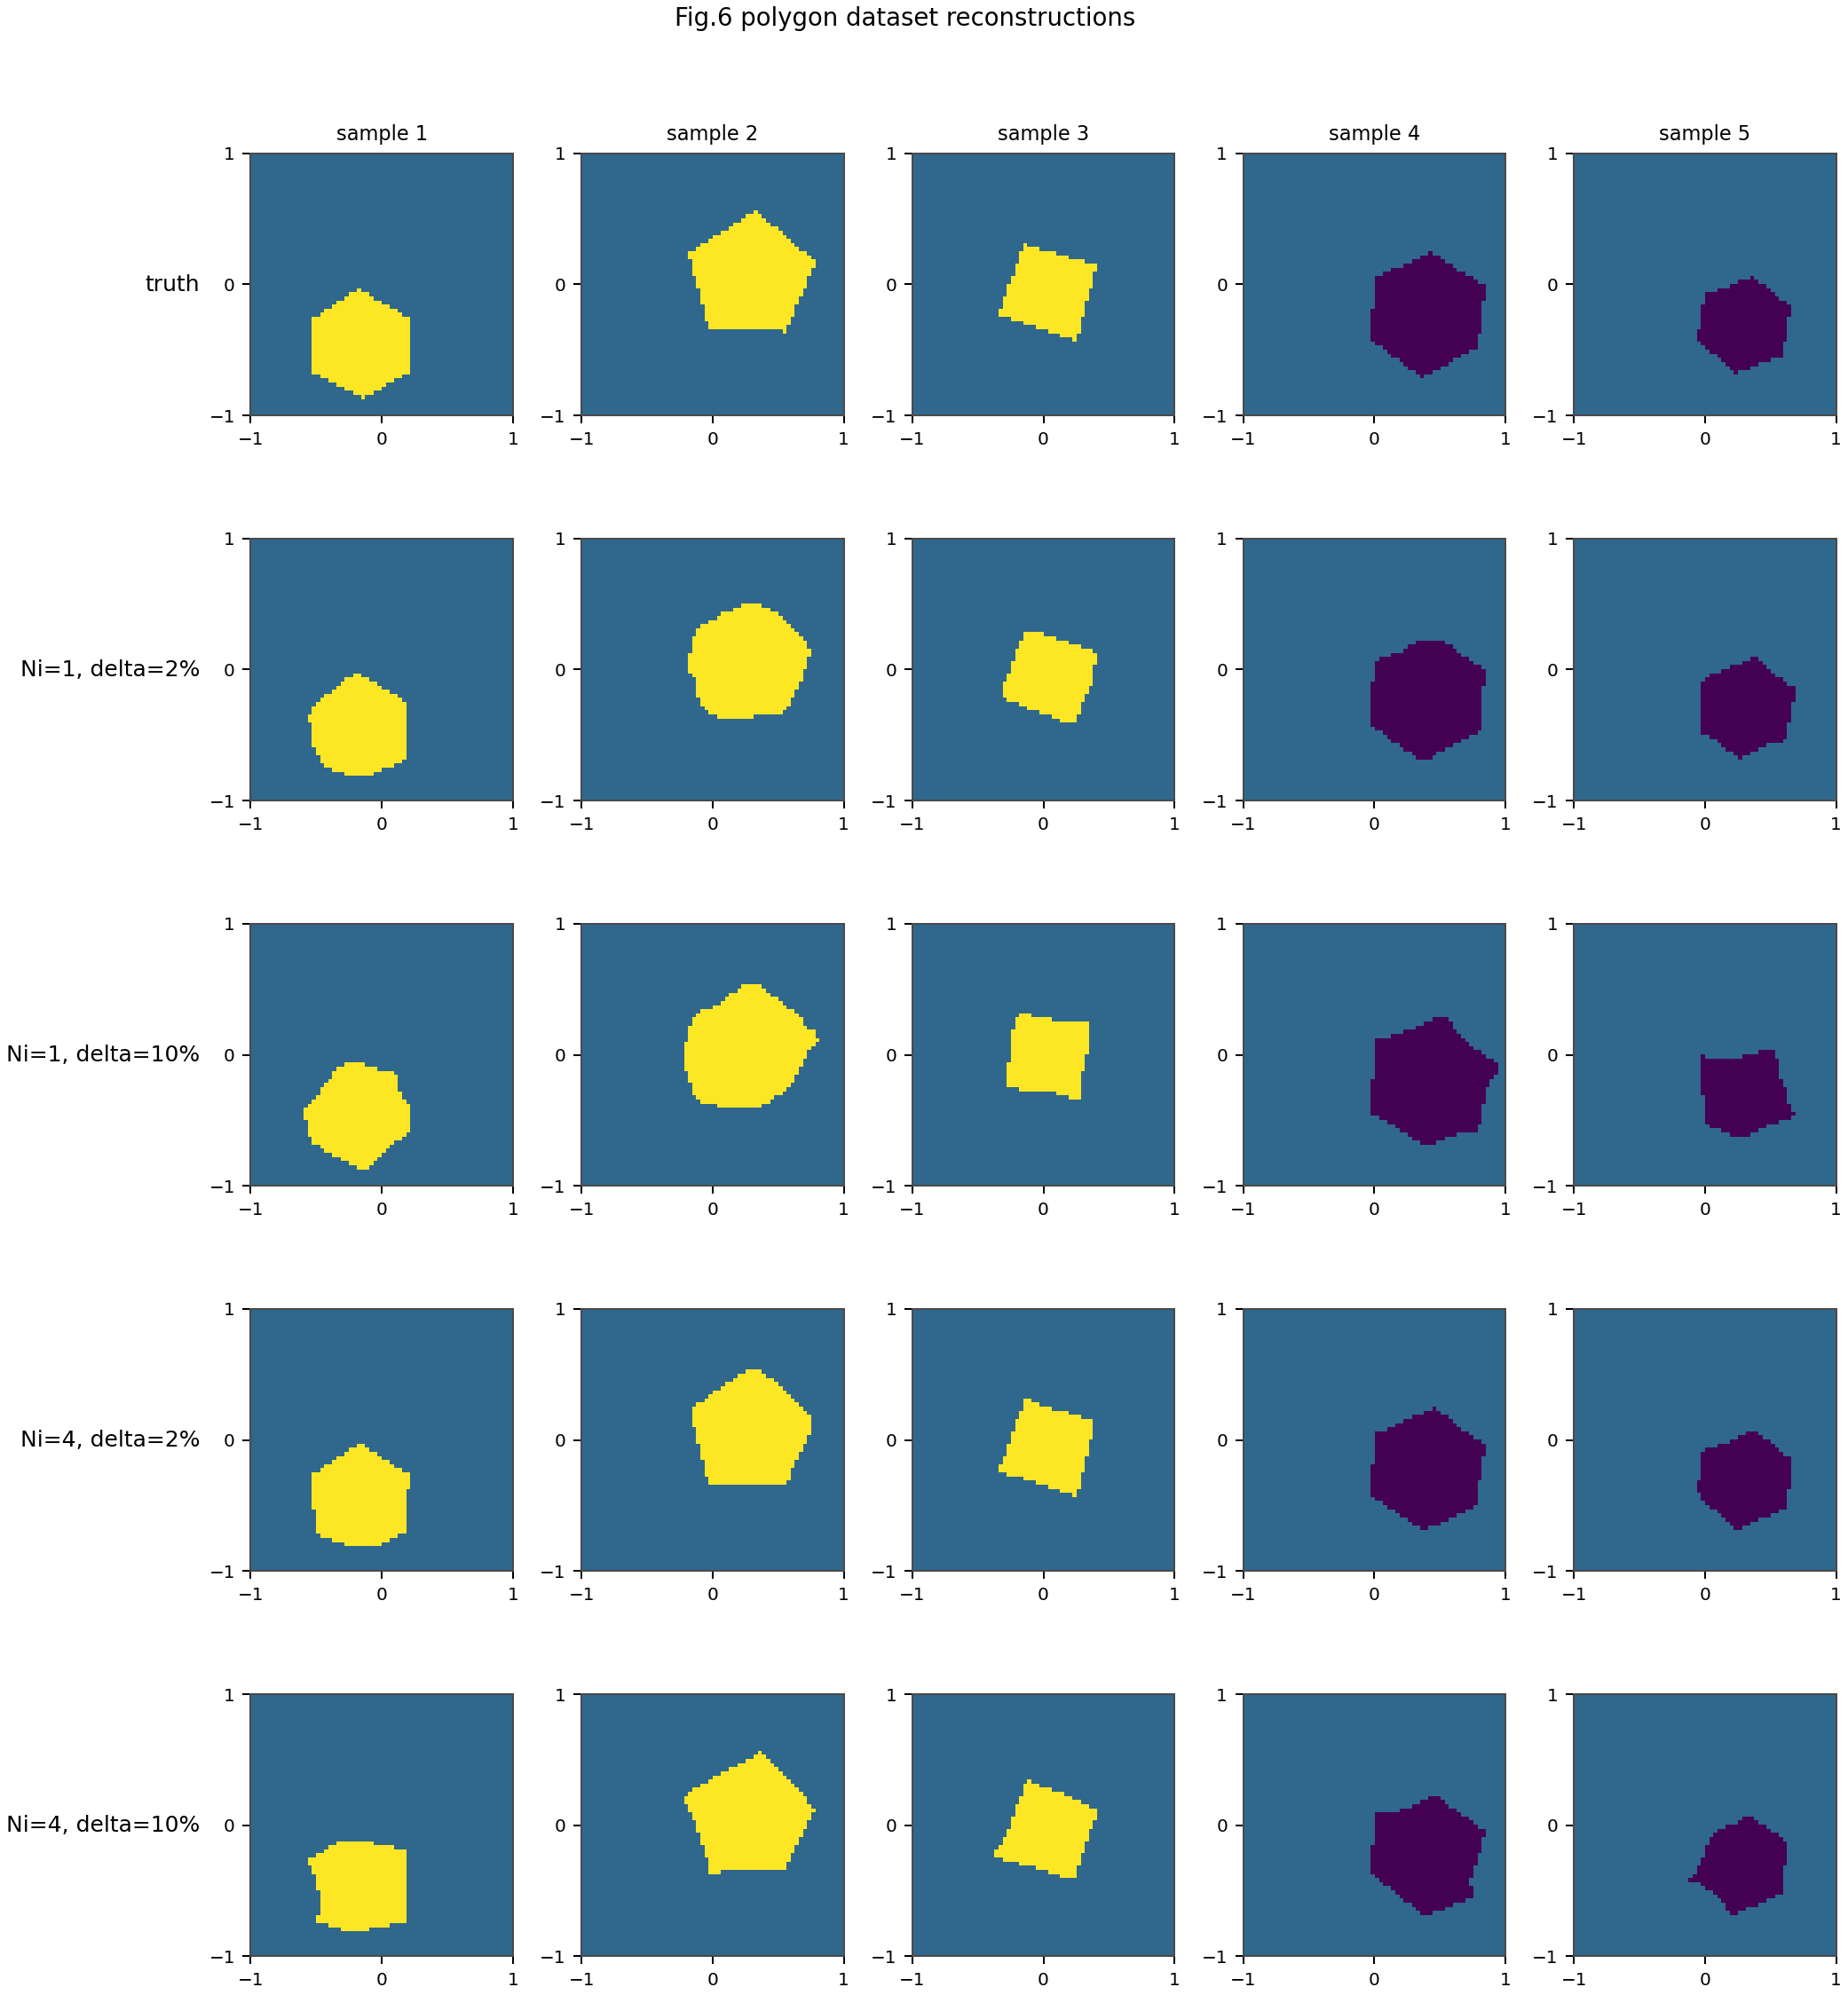

06_paper_fig7_mnist.png


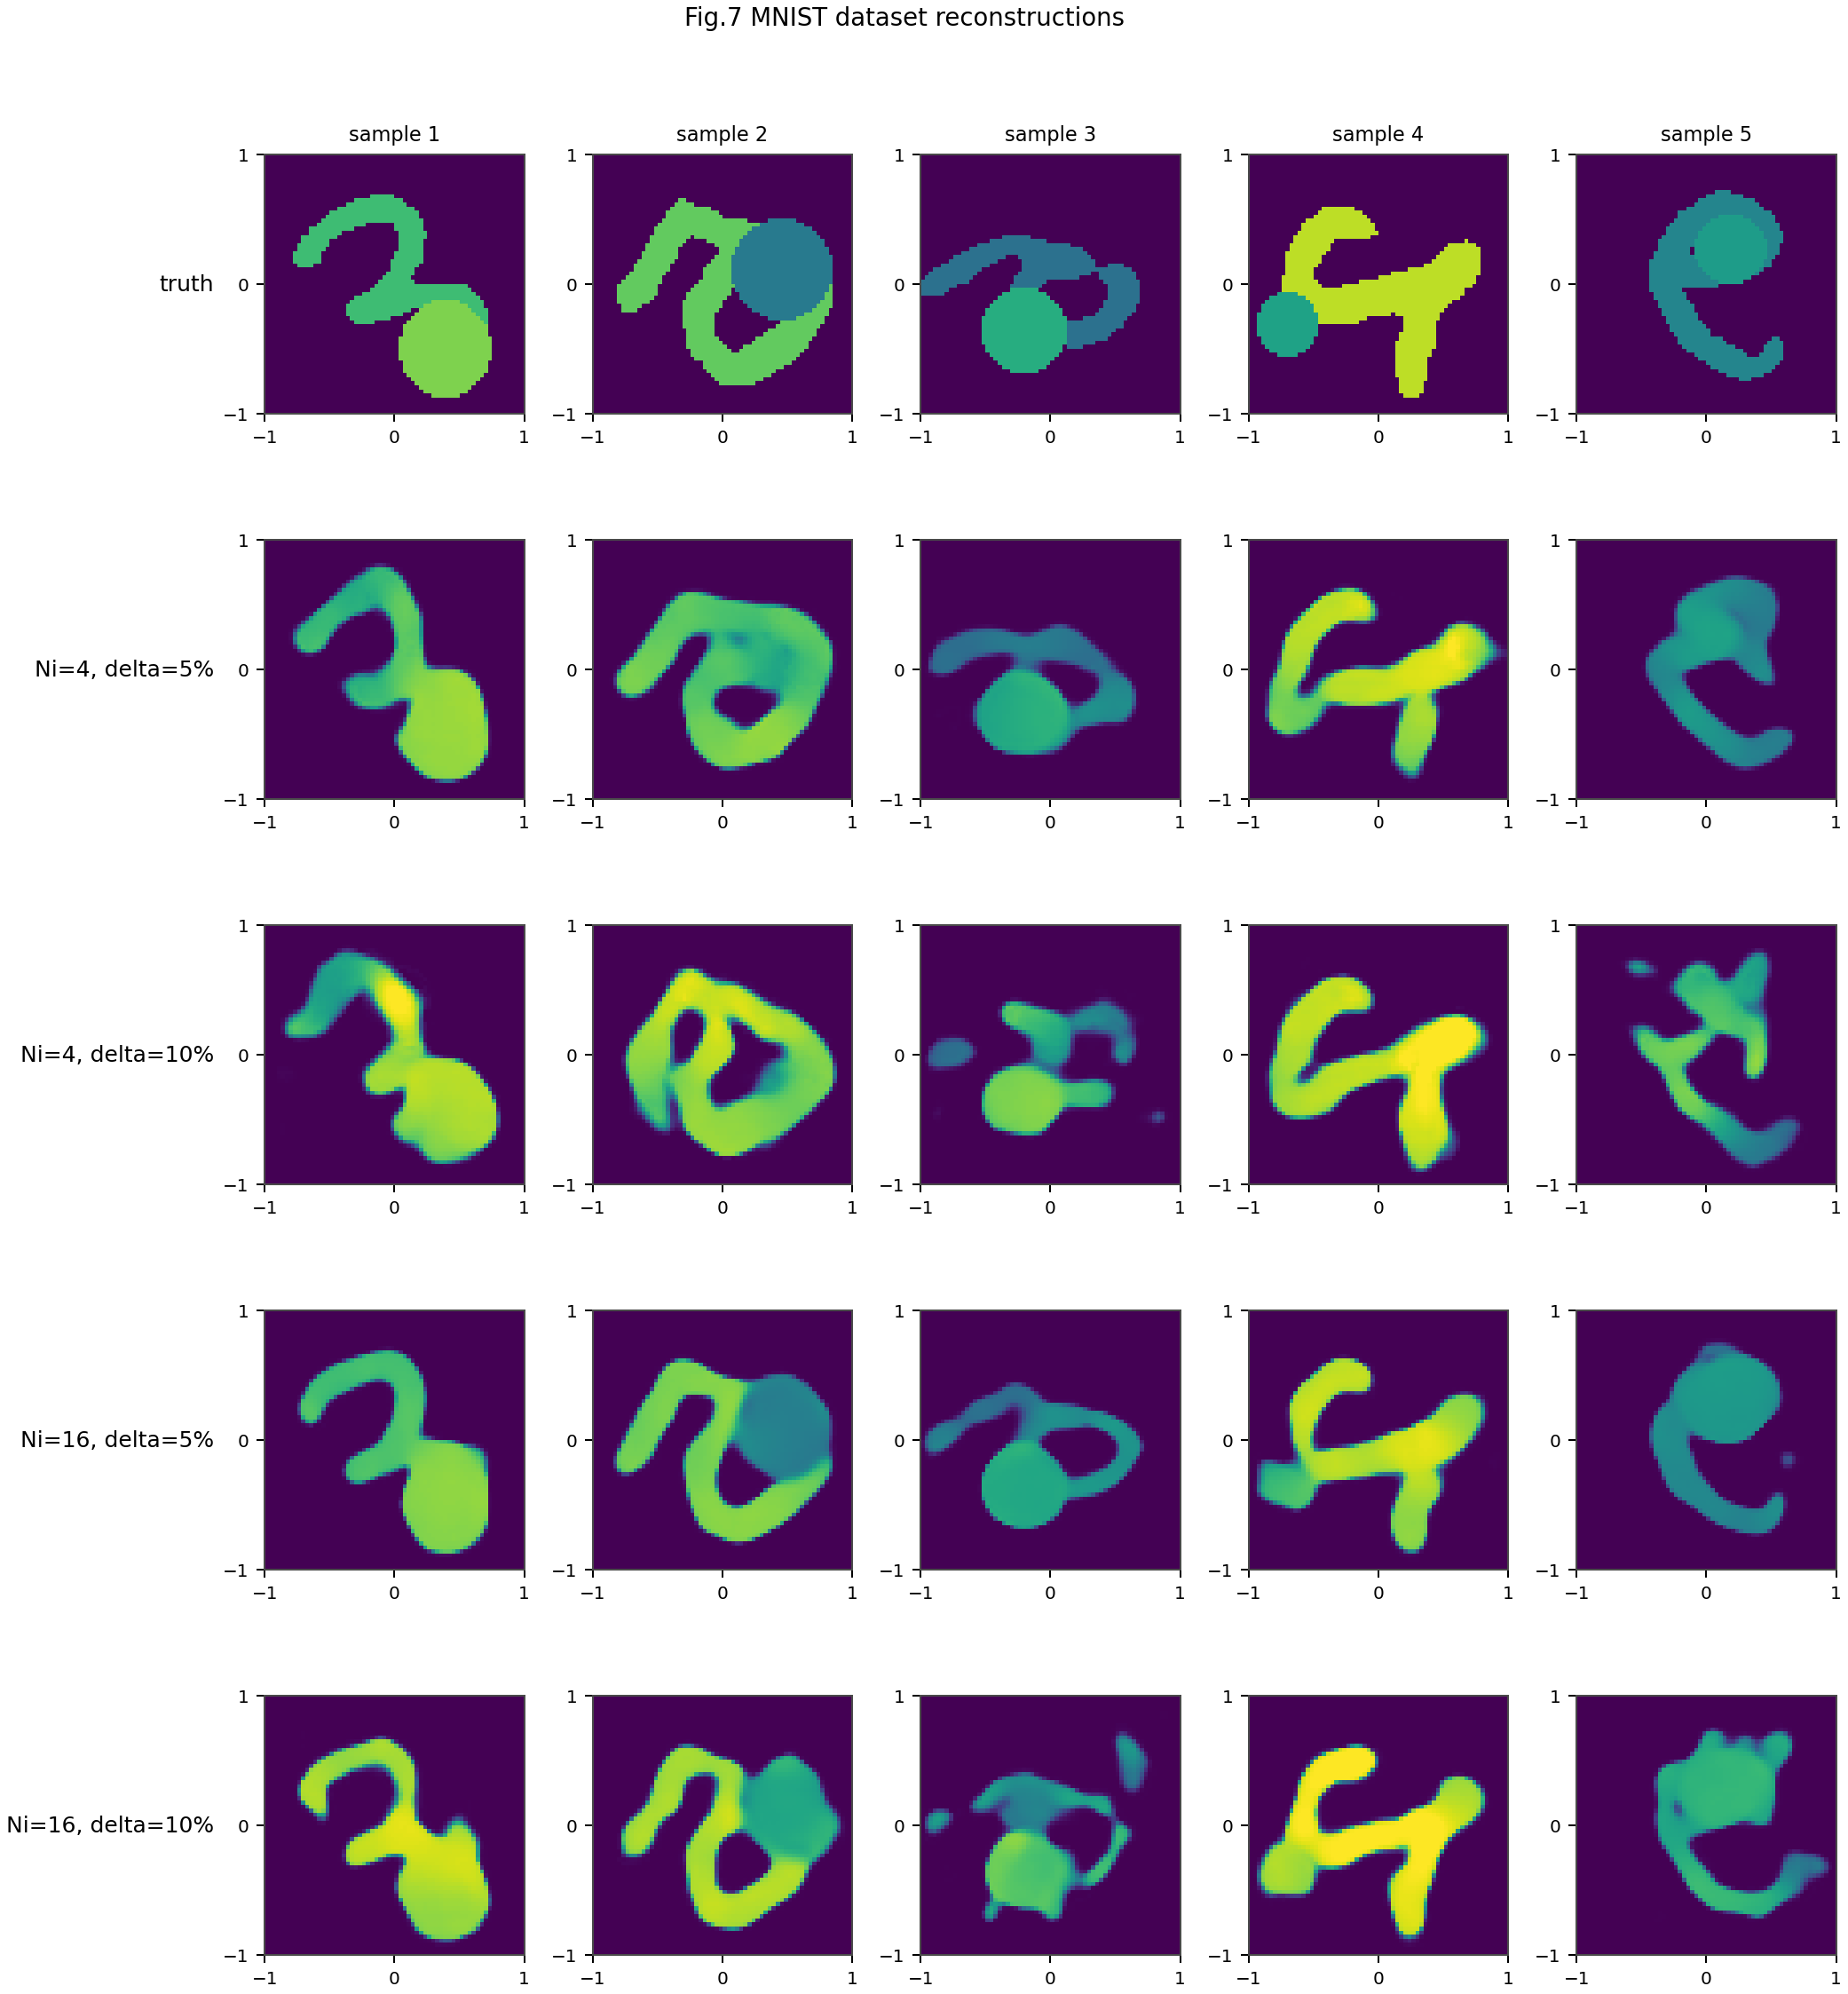

06_paper_fig8_chinese.png


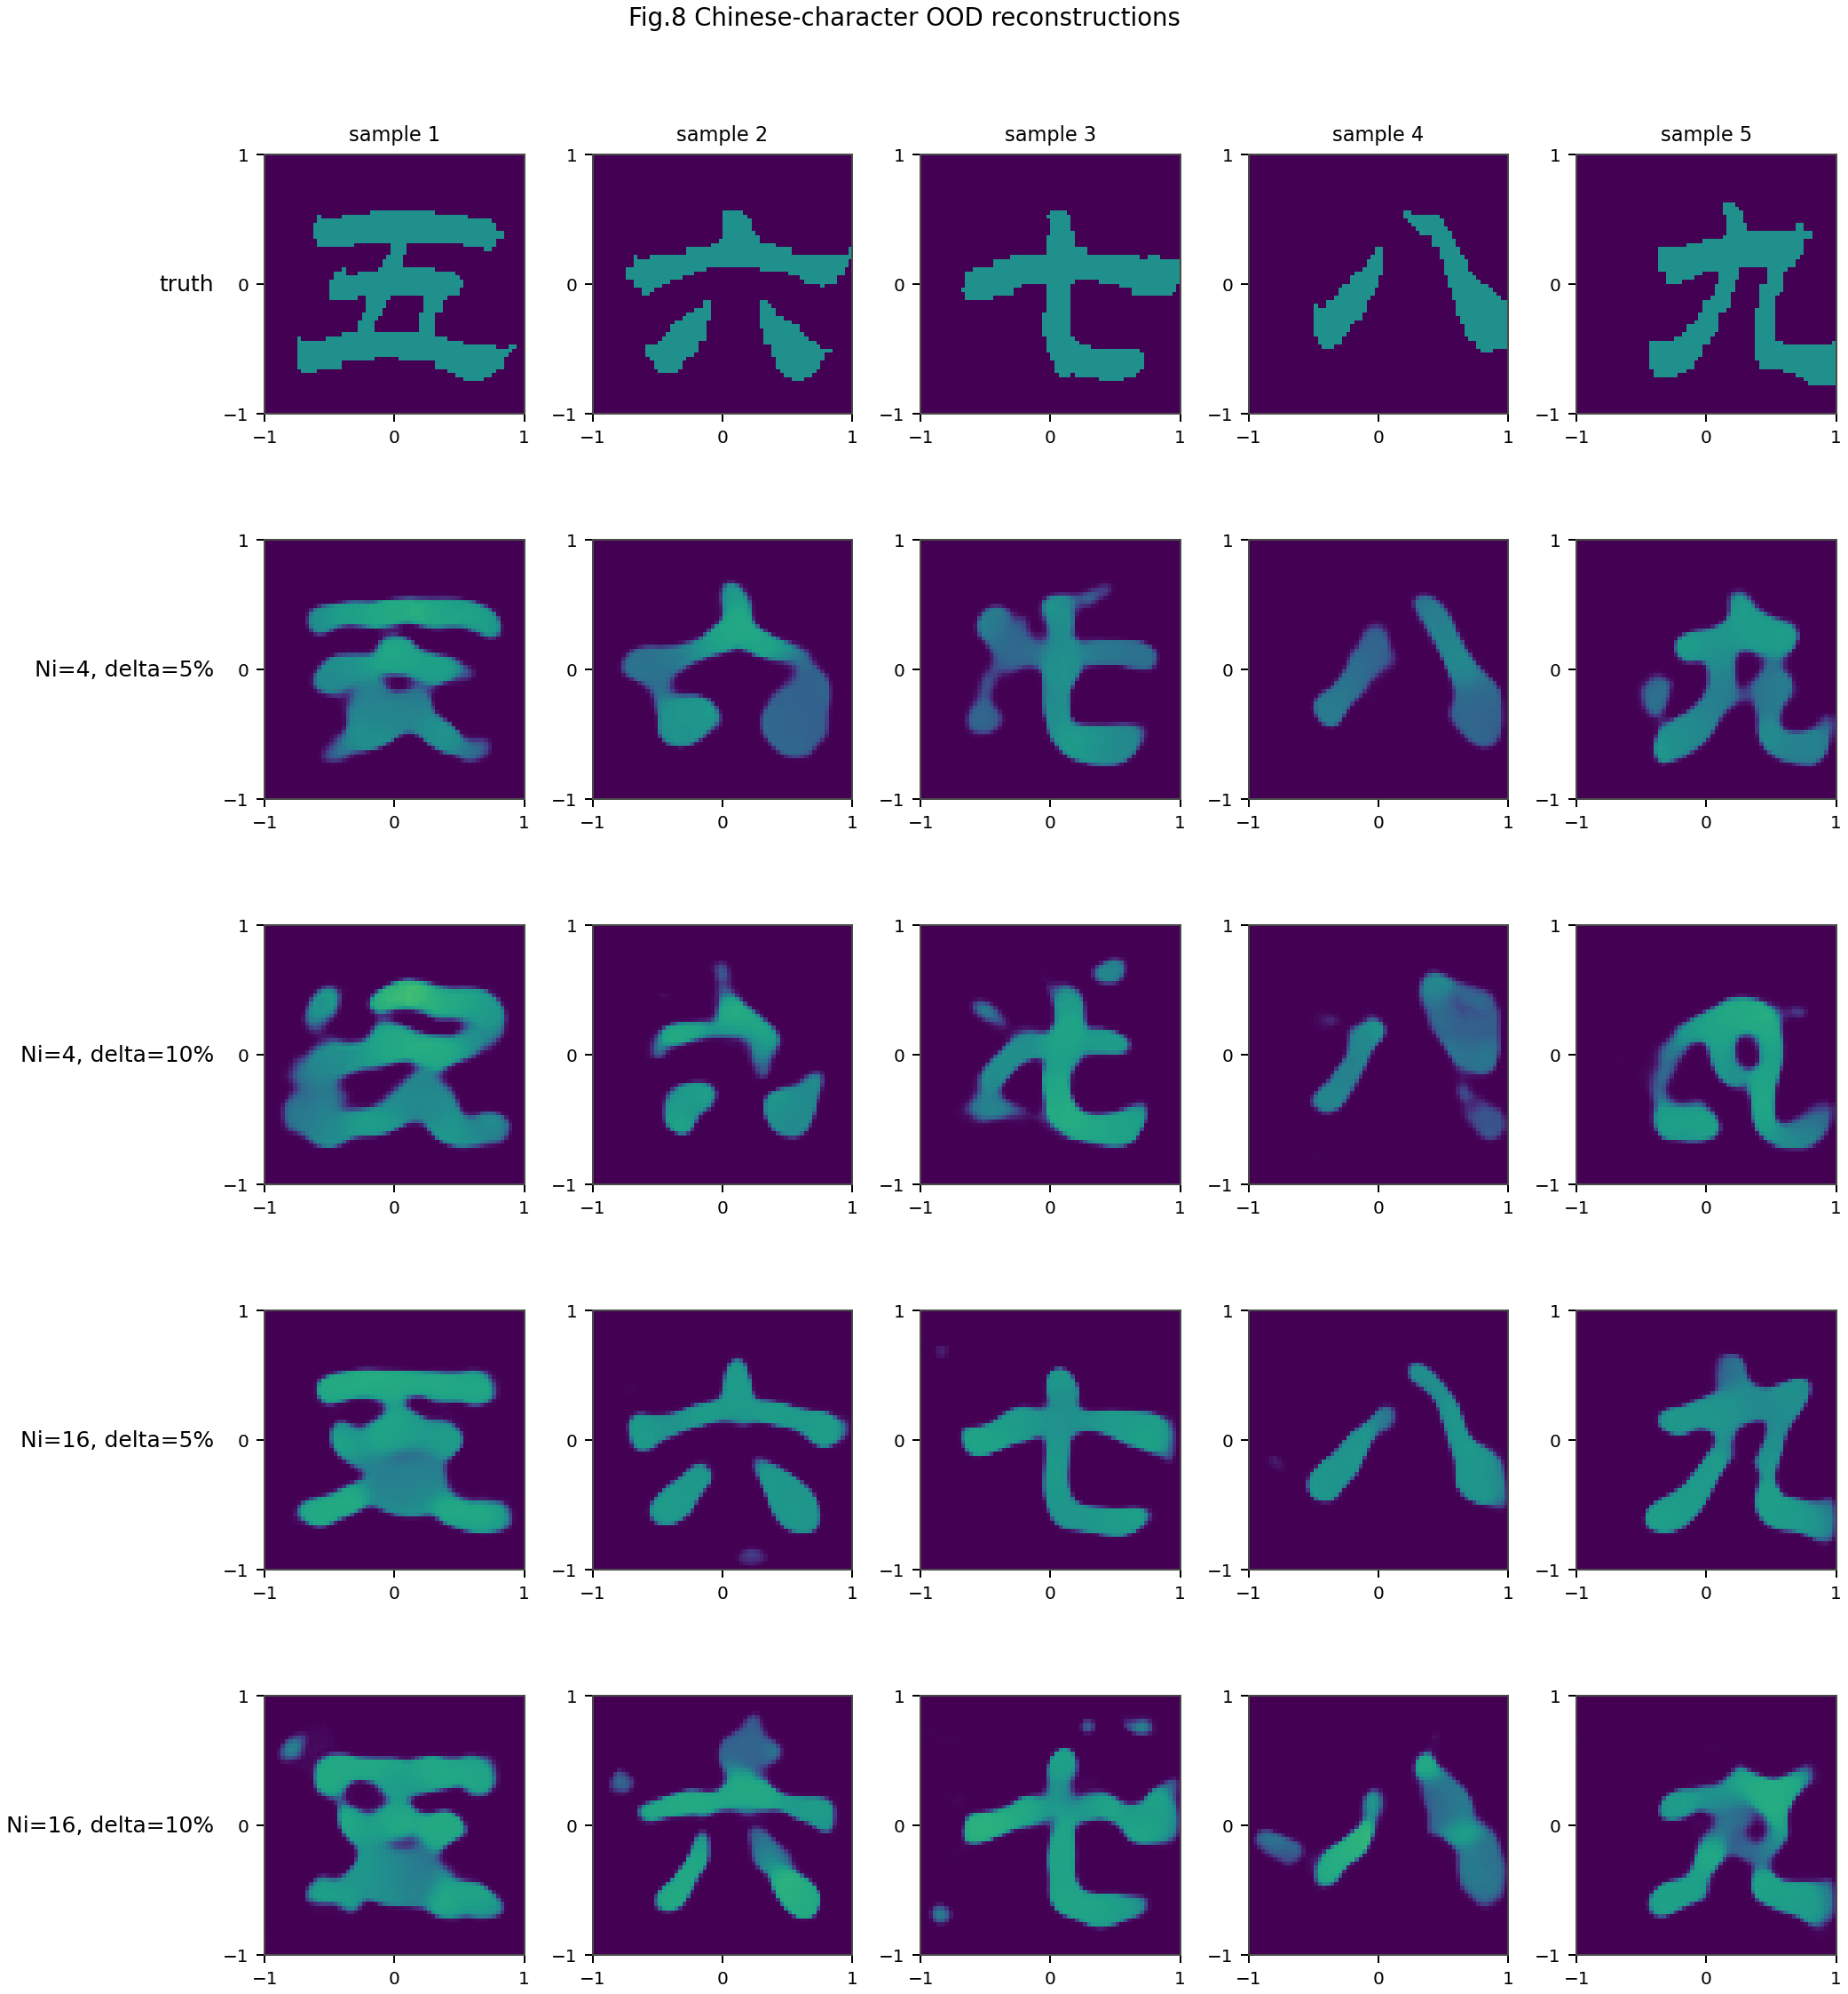

06_paper_fig9_austria.png


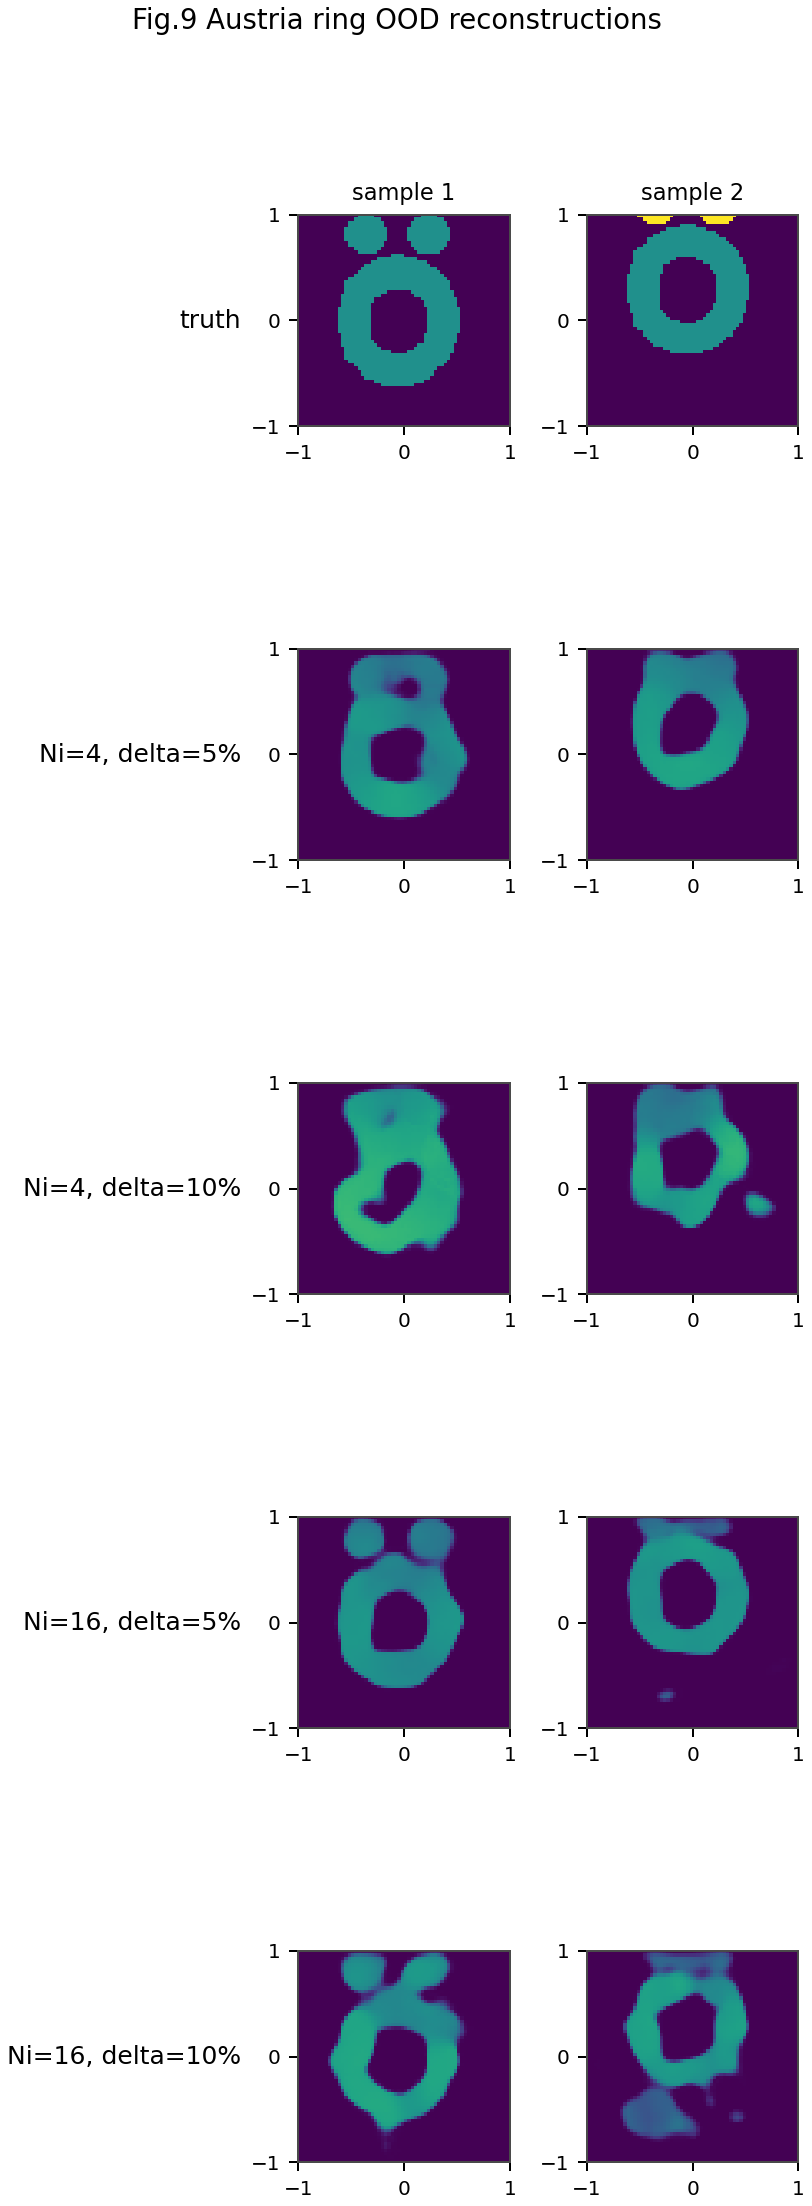

06_paper_fig10_mixed.png


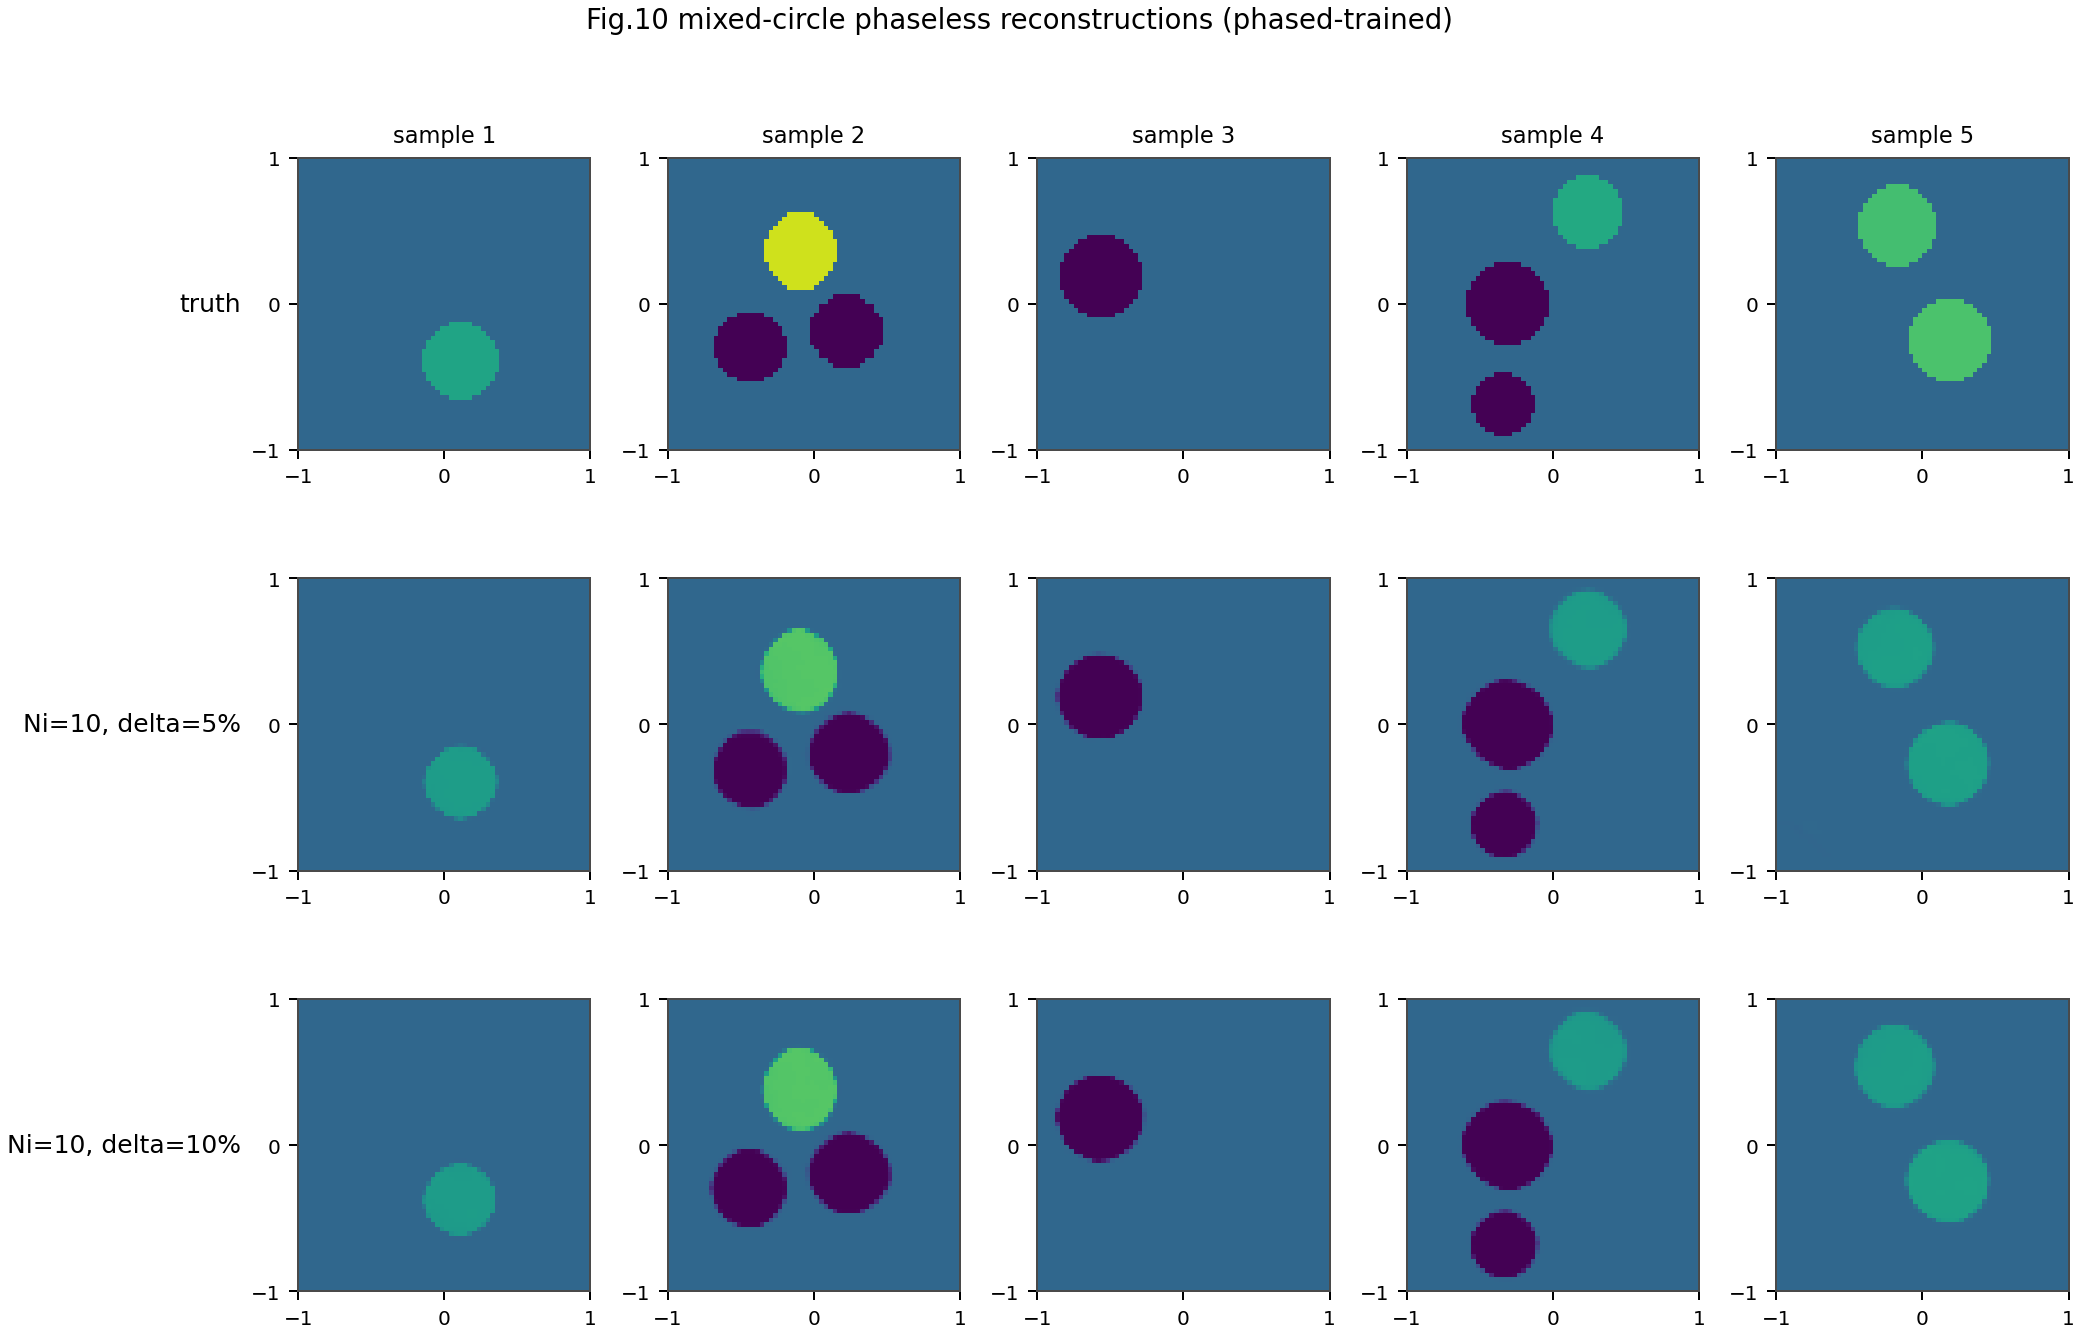

In [10]:
from IPython.display import Image, display

figure_paths = [
    FIG_DIR / '06_paper_fig6_polygon.png',
    FIG_DIR / '06_paper_fig7_mnist.png',
    FIG_DIR / '06_paper_fig8_chinese.png',
    FIG_DIR / '06_paper_fig9_austria.png',
    FIG_DIR / '06_paper_fig10_mixed.png',
]
for path in figure_paths:
    if path.exists():
        print(path.name)
        display(Image(filename=str(path)))
    else:
        print(f'missing: {path} (run scripts/run_phaseless_full_repro.py first)')

## 11. Summary and Discussion

### Phase 6 deliverables

| Paper component | Notebook reference |
|---|---|
| Helmholtz forward + phaseless DSM | Sections 1–3 call `run_example_dsm_paper`; the corrected-data and indicator formulas are displayed above |
| Section 5.1 Examples 1–4 figures | Sections 6–7 (`06_paper_fig2_4_examples1_3.png`, `06_paper_fig5_ring_ni_sweep.png`) |
| DSM peak / support diagnostics | Section 4 |
| Section 5.2.1 polygon DSM-DL (Table 1) | Section 9 comparison + `06_paper_fig6_polygon.png` |
| Section 5.2.2 MNIST + Chinese / Austria OOD (Table 2) | Section 9 comparison + `06_paper_fig7_mnist.png`, `06_paper_fig8_chinese.png`, `06_paper_fig9_austria.png` |
| Section 5.2.3 mixed-circle (phased train → phaseless test) | Section 9 metrics + `06_paper_fig10_mixed.png` |
| Paper Table 1 / Table 2 comparison | Section 5 |

### Reference-code Python port

The original reference packages are now runnable in Python-only form:

- forward generation (MATLAB `DataMnist.m` logic): `scripts/run_phaseless_forward_generate.py`,
- DSMDL training (PyTorch `main.py` + `U_Net3Ab` logic): `scripts/run_phaseless_port_repro.py`,
- API module: `src/phaseless_reference.py`.

This path is kept separate from the paper path so their physics, scaling, and training choices can be compared clearly.

### Key claim of Section 5.2.3 (phased-trained → phaseless inference)

The phased index is

$$
I_{\mathrm{DSM}}(z)
=\left|\int_{\Gamma_r}G(z,x_r)\overline{u^s(x_r)}\,ds(x_r)\right|,
$$

whereas the phaseless index is

$$
I_{\mathrm{DSM}}^{\mathrm{phaseless}}(z)
=\left|\int_{\Gamma_r}G(z,x_r)\Delta(x_r,d)\,ds(x_r)\right|.
$$

The paper's headline observation is that a DSM-DL network trained with the first input can still produce accurate reconstructions when runtime evaluation uses the second input. The full training script selects phased training for the mixed-circle case and evaluates it with the phaseless simulator.

### Comparison with previous phases

| Aspect | Phases 1–5 (elliptic/parabolic) | Phase 6 (Helmholtz phaseless) |
|---|---|---|
| Forward operator | $-\nabla\!\cdot(\sigma\nabla\cdot)$ (+ time / potential) | $\Delta + k^2 n(x)$ |
| Measurement | Cauchy pair $(f, y^d)$ | Phaseless magnitude $|u|$ on $\Gamma_r$ |
| Inversion path | IDSM / DSM with regularized DtN | DSM index → U-Net regression |
| Loss / regularization | Implicit via low-rank DFP/BFG | Explicit $\|X-Y\|_2^2+\alpha_1\operatorname{TV}(X)+\alpha_2(1-\operatorname{SSIM})$ |
| Coefficient recovery | $\sigma$, $V$, $U$ time-dependent | $n(x)$ with cutoff $\{0,1,3\}$ |

The essential new ingredient is the dual use of DSM as a robust prior for a learned inverse, which lets a single network handle medium scatterers and impenetrable scatterers in a unified framework even when only phaseless data is available.

## Appendix A — Expanded Paper Equation Reference

This track follows arXiv:2403.02584 directly.

**Eq. (2.3): obstacle boundary conditions**

$$
\left\{\begin{aligned}
u&=0 &&\text{on }\partial D &&\text{(sound soft)},\\
\partial_\nu u&=0 &&\text{on }\partial D &&\text{(sound hard)},\\
\partial_\nu u+\mathrm{i}k\lambda u&=0 &&\text{on }\partial D &&\text{(impedance)}.
\end{aligned}\right.
$$

**Eq. (2.4): inhomogeneous medium equation**

$$
\Delta u+k^2n(x)u=0
\qquad\text{in }\mathbb{R}^N.
$$

**Eq. (2.5): scattered-field far-field expansion**

$$
u^s(x)=
\frac{e^{\mathrm{i}k|x|}}{|x|^{(N-1)/2}}
\left[u^\infty(\widehat x)+\mathcal{O}\left(|x|^{-1}\right)\right],
\qquad |x|\to\infty.
$$

**Eq. (5.1): noisy phaseless data**

$$
|u_\delta(x)|=|u(x)|+\delta\,\zeta(x)\,\|u\|_2,
\qquad x\in\Gamma_r.
$$

**Eq. (3.12): corrected phaseless data**

$$
\Delta(x_r,d)=
\frac{|u(x_r,d)|^2-|u^i(x_r,d)|^2}{u^i(x_r,d)}.
$$

**Eq. (3.11): phaseless DSM indicator**

$$
I_{\mathrm{DSM}}^{\mathrm{phaseless}}(z)
=\left|\int_{\Gamma_r}G(z,x_r)\Delta(x_r,d)\,ds(x_r)\right|,
\qquad z\in\Omega.
$$

**Eq. (5.2): multi-incidence average**

$$
I(z)=\frac{1}{N_i}\sum_{i=1}^{N_i}I_i(z).
$$

In [11]:
# The strict VIE/BIE equation chain is executed in Section 1.

## Appendix B — DSM-DL Formula Reference

**Eq. (4.1): DSM-DL loss**

$$
\mathrm{Loss}
=\frac{1}{T_n}\sum_{i=1}^{T_n}
\left[
\|X_i-Y_i\|_2^2
+\alpha_1\operatorname{TV}(X_i)
+\alpha_2\left(1-\operatorname{SSIM}(X_i,Y_i)\right)
\right].
$$

**Eq. (5.3): relative $L^2$ error**

$$
R_e(X,Y)=\frac{\|X-Y\|_2}{\|Y\|_2}.
$$

**Eq. (5.4): pixel accuracy**

$$
\operatorname{Acc}(X,Y)
=\frac{1}{N_{d_x}N_{d_y}}
\sum_{i=1}^{N_{d_x}}\sum_{j=1}^{N_{d_y}}a_{i,j},
\qquad
a_{i,j}=\begin{cases}
1,&X_{i,j}=Y_{i,j},\\
0,&\text{otherwise}.
\end{cases}
$$

We now build a small polygon dataset, compare phased and phaseless tensors, inspect `UNetDSMDL`, print the three loss terms separately, run a short training loop, and evaluate both metrics.

In [12]:
# The traced DSM-DL mechanics check is executed in Section 2.

## Appendix C — Released-Source Reminder

The exact source-line mapping and the executable physical MoM chain are provided in Section 3. The notes below summarize the same correspondence.

The code cells in this track use only `src.phaseless_reference` APIs, while mapping each step to the restored source files:

- `annulus_gen_rand`  ⇔  `ISP_forward/annulus_gen_rand.m` (random circle geometry and permittivity).
- `generate_forward_dataset` / `ForwardConfig`  ⇔  `ISP_forward/DataMnist.m` (MoM setup, receiver ring, incidence loop).
- `select_incidence_indices` and `compute_inputs_from_fields`  ⇔  `DSMDL_phaseless/main.py` (`index`, `norm_Gs`, correction term, `2.0/mm`).
- `UNet3Ab` and `train_unet3ab`  ⇔  `DSMDL_phaseless/network.py` + `main.py` (U-Net blocks, TV/SSIM weights, batch slicing, scheduler, checkpoint rule).
- plotting style note  ⇔  `DSMDL_phaseless/colorMap.py` (`parula`).

In [13]:
# The released MoM and U_Net3Ab chain is executed in Section 3.

In [14]:
# The physical small-grid MoM forward output is already inspected in Section 3.

## Appendix D — Compact Path Comparison

| Topic | Paper Track (arXiv:2403.02584) | Reference Track (`ISP_forward` + `DSMDL_phaseless`) |
|---|---|---|
| Forward model | Displayed Helmholtz medium/obstacle equations, VIE + BIE | MoM data synthesis in `DataMnist.m`, then indicator + U-Net training in `main.py` |
| Corrected data | $\Delta=(|u|^2-|u^i|^2)/u^i$ | `deltaE` / `deltaE_Noise` expressions in `main.py` |
| Indicator | $I(z)=|\int_{\Gamma_r}G(z,x_r)\Delta(x_r,d)\,ds|$, averaged over incidences | `torch.matmul(..., Gs)` then reshape/transposes in `main.py` |
| Input scaling | paper normalization for indicator display | fixed `2.0/mm` with `mm=500` in `main.py` |
| Network | U-Net encoder/decoder (paper Fig. 1) | `U_Net3Ab` in `network.py` |
| Loss | $\|X-Y\|_2^2+\alpha_1\operatorname{TV}(X)+\alpha_2(1-\operatorname{SSIM})$ | same structure in `main.py` with TV/SSIM weights `0.05, 0.05` |
| Training policy | paper epoch schedule in Section 5.2 | contiguous batch slicing, StepLR, keep smallest test error checkpoint |
| Plot style | paper figure conventions | `parula` colormap in `colorMap.py` |

Both tracks are now runnable in Python and are intentionally kept side-by-side: the first follows the paper equations directly, while the second follows the released implementation choices.

### Appendix Formula Recap

$$
|u_\delta|=|u|+\delta\zeta\|u\|_2
$$

maps to `add_phaseless_noise`.

$$
\Delta=\frac{|u|^2-|u^i|^2}{u^i}
$$

maps to `corrected_phaseless_data`.

$$
I_{\mathrm{DSM}}^{\mathrm{phaseless}}(z)
=\left|\int_{\Gamma_r}G(z,x_r)\Delta(x_r,d)\,ds\right|
$$

maps to `compute_phaseless_dsm_indicator`.

$$
I(z)=\frac{1}{N_i}\sum_{i=1}^{N_i}I_i(z)
$$

maps to manual accumulation and the `run_example_dsm_paper` comparison.

$$
\mathrm{Loss}=\frac1{T_n}\sum_i
\left[\|X_i-Y_i\|_2^2+\alpha_1\operatorname{TV}(X_i)
+\alpha_2(1-\operatorname{SSIM}(X_i,Y_i))\right]
$$

maps to the separately printed MSE, TV, and SSIM terms. The reference path maps `annulus_gen_rand`, `generate_forward_dataset`, `compute_inputs_from_fields`, `UNet3Ab`, and `train_unet3ab` through `src.phaseless_reference`.